In [ ]:
import re
import os
from tqdm import tqdm

def should_split_at_comma(text, comma_index):
    """
    Kiểm tra xem dấu phẩy có nên được sử dụng để tách câu hay không
    """
    # Kiểm tra nếu dấu phẩy nằm trong ngoặc đơn, ngoặc kép hoặc ngoặc vuông
    open_brackets = 0
    open_parentheses = 0
    open_square_brackets = 0
    in_quotes = False
    
    for i in range(comma_index):
        if text[i] == '(' and not in_quotes:
            open_parentheses += 1
        elif text[i] == ')' and not in_quotes:
            open_parentheses -= 1
        elif text[i] == '[' and not in_quotes:
            open_square_brackets += 1
        elif text[i] == ']' and not in_quotes:
            open_square_brackets -= 1
        elif text[i] == '"':
            in_quotes = not in_quotes
    
    if open_parentheses > 0 or open_square_brackets > 0 or in_quotes:
        return False
    
    # Kiểm tra nếu dấu phẩy là một phần của số thập phân
    if comma_index > 0 and comma_index < len(text) - 1:
        if text[comma_index-1].isdigit() and text[comma_index+1].isdigit():
            return False
    
    # Kiểm tra nếu dấu phẩy trong viết tắt hoặc một số trường hợp đặc biệt khác
    # Ví dụ: "Ông A, Bà B và C đã đến"
    # Nếu sau dấu phẩy là chữ cái đơn, không tách
    if comma_index < len(text) - 3:
        after_comma = text[comma_index+1:comma_index+4].strip()
        if len(after_comma) == 1 and after_comma.isalpha():
            return False
    
    return True

def split_long_sentences(input_file, output_file):
    """
    Đọc file văn bản, tách các câu dài thành các câu ngắn hơn dựa trên dấu phẩy,
    và ghi kết quả vào file output
    """
    try:
        with open(input_file, 'r', encoding='utf-8') as f:
            content = f.readlines()
        
        total_lines = len(content)
        print(f"Đang xử lý {total_lines} dòng...")
        
        result = []
        for line in tqdm(content):
            line = line.strip()
            if not line:  # Bỏ qua dòng trống
                continue
                
            # Tách câu bằng dấu chấm trước
            sentences = re.split(r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?|\!)\s', line)
            
            processed_sentences = []
            for sentence in sentences:
                sentence = sentence.strip()
                if not sentence:
                    continue
                    
                # Xác định vị trí của tất cả các dấu phẩy
                comma_positions = [m.start() for m in re.finditer(',', sentence)]
                
                if not comma_positions:
                    # Không có dấu phẩy, giữ nguyên câu
                    processed_sentences.append(sentence)
                    continue
                
                # Lọc các vị trí dấu phẩy mà ta muốn tách
                split_positions = [pos for pos in comma_positions if should_split_at_comma(sentence, pos)]
                
                if not split_positions:
                    # Không có dấu phẩy nào để tách, giữ nguyên câu
                    processed_sentences.append(sentence)
                    continue
                
                # Tách câu tại các vị trí đã xác định
                prev_pos = 0
                for pos in split_positions:
                    subclauses = sentence[prev_pos:pos].strip()
                    if subclauses:
                        processed_sentences.append(subclauses)
                    prev_pos = pos + 1
                
                # Thêm phần cuối cùng
                last_part = sentence[prev_pos:].strip()
                if last_part:
                    processed_sentences.append(last_part)
            
            result.extend(processed_sentences)
        
        # Ghi kết quả ra file
        with open(output_file, 'w', encoding='utf-8') as f:
            for sent in result:
                f.write(sent + '\n')
        
        print(f"Đã xử lý xong! Kết quả được lưu tại: {output_file}")
        print(f"Số câu đầu vào: {total_lines}")
        print(f"Số câu đầu ra: {len(result)}")
        
    except Exception as e:
        print(f"Có lỗi xảy ra: {str(e)}")

def process_file():
    """
    Hàm chính để xử lý file
    """
    input_file = "raw_data/crawled_news_pagination.txt"
    output_file = "raw_data/full_raw_data_tach_cau.txt"
    
    if not os.path.exists(input_file):
        print(f"File {input_file} không tồn tại!")
        return
    
    split_long_sentences(input_file, output_file)


In [2]:
process_file()

Đang xử lý 91976 dòng...


100%|██████████| 91976/91976 [00:02<00:00, 34367.80it/s]


Đã xử lý xong! Kết quả được lưu tại: raw_data/full_raw_data_tach_cau.txt
Số câu đầu vào: 91976
Số câu đầu ra: 243809


In [3]:
import re
import os
from tqdm import tqdm

def contains_special_chars(text):
    """
    Kiểm tra xem chuỗi có chứa ký tự đặc biệt ngoài chữ, số, dấu phẩy và dấu chấm hay không
    """
    # Mẫu regex để tìm các ký tự đặc biệt ngoài chữ, số, dấu phẩy, dấu chấm và khoảng trắng
    # Bao gồm tất cả các ký tự tiếng Việt có dấu
    pattern = r'[^\w\s.,àáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđÀÁẢÃẠĂẮẰẲẴẶÂẤẦẨẪẬÈÉẺẼẸÊẾỀỂỄỆÌÍỈĨỊÒÓỎÕỌÔỐỒỔỖỘƠỚỜỞỠỢÙÚỦŨỤƯỨỪỬỮỰỲÝỶỸỴĐ]'
    
    # Tìm kiếm ký tự đặc biệt
    special_chars = re.findall(pattern, text)
    return len(special_chars) > 0

def filter_sentences(input_file, output_file):
    """
    Đọc file văn bản đã tách câu, loại bỏ các câu chứa ký tự đặc biệt
    """
    try:
        # Đọc file đầu vào
        with open(input_file, 'r', encoding='utf-8') as f:
            sentences = f.readlines()
        
        total_sentences = len(sentences)
        print(f"Đang xử lý {total_sentences} câu...")
        
        # Lọc các câu không chứa ký tự đặc biệt
        filtered_sentences = []
        removed_count = 0
        
        for sentence in tqdm(sentences):
            sentence = sentence.strip()
            if not sentence:  # Bỏ qua dòng trống
                continue
            
            # Kiểm tra nếu câu chứa ký tự đặc biệt
            if contains_special_chars(sentence):
                removed_count += 1
                continue
            
            # Thêm câu vào danh sách kết quả
            filtered_sentences.append(sentence)
        
        # Ghi kết quả ra file
        with open(output_file, 'w', encoding='utf-8') as f:
            for sent in filtered_sentences:
                f.write(sent + '\n')
        
        print(f"Đã xử lý xong! Kết quả được lưu tại: {output_file}")
        print(f"Số câu đầu vào: {total_sentences}")
        print(f"Số câu bị loại bỏ vì chứa ký tự đặc biệt: {removed_count}")
        print(f"Số câu đầu ra: {len(filtered_sentences)}")
        
    except Exception as e:
        print(f"Có lỗi xảy ra: {str(e)}")

def process_file():
    """
    Hàm chính để xử lý file
    """
    input_file = "raw_data/full_raw_data_tach_cau.txt"
    output_file = "raw_data/full_raw_data_loai_ky_tu_dac_biet.txt"
    
    if not os.path.exists(input_file):
        print(f"File {input_file} không tồn tại!")
        return
    
    filter_sentences(input_file, output_file)


In [4]:
process_file()

Đang xử lý 243809 câu...


100%|██████████| 243809/243809 [00:00<00:00, 433662.29it/s]


Đã xử lý xong! Kết quả được lưu tại: raw_data/full_raw_data_loai_ky_tu_dac_biet.txt
Số câu đầu vào: 243809
Số câu bị loại bỏ vì chứa ký tự đặc biệt: 52465
Số câu đầu ra: 191344


In [5]:
import re
import os
from tqdm import tqdm

def has_consecutive_digits(text):
    """
    Kiểm tra xem chuỗi có chứa 2 chữ số liền kề trở lên hay không
    """
    # Tìm các chuỗi chứa ít nhất 2 chữ số liền kề
    pattern = r'\d{2,}'
    match = re.search(pattern, text)
    return match is not None

def clean_and_filter_sentences(input_file, output_file):
    """
    Đọc file văn bản, loại bỏ dấu chấm và dấu phẩy, 
    loại bỏ câu chứa 2 chữ số liền kề trở lên
    """
    try:
        # Đọc file đầu vào
        with open(input_file, 'r', encoding='utf-8') as f:
            sentences = f.readlines()
        
        total_sentences = len(sentences)
        print(f"Đang xử lý {total_sentences} câu...")
        
        # Lọc và làm sạch các câu
        cleaned_sentences = []
        removed_digits_count = 0
        
        for sentence in tqdm(sentences):
            sentence = sentence.strip()
            if not sentence:  # Bỏ qua dòng trống
                continue
            
            # Kiểm tra nếu câu chứa 2 chữ số liền kề trở lên
            if has_consecutive_digits(sentence):
                removed_digits_count += 1
                continue
            
            # Loại bỏ dấu chấm và dấu phẩy
            cleaned_sentence = sentence.replace('.', '').replace(',', '')
            
            # Thêm câu đã làm sạch vào danh sách kết quả
            cleaned_sentences.append(cleaned_sentence)
        
        # Ghi kết quả ra file
        with open(output_file, 'w', encoding='utf-8') as f:
            for sent in cleaned_sentences:
                f.write(sent + '\n')
        
        print(f"Đã xử lý xong! Kết quả được lưu tại: {output_file}")
        print(f"Số câu đầu vào: {total_sentences}")
        print(f"Số câu bị loại bỏ vì chứa 2+ chữ số liền kề: {removed_digits_count}")
        print(f"Số câu đầu ra: {len(cleaned_sentences)}")
        
    except Exception as e:
        print(f"Có lỗi xảy ra: {str(e)}")

def process_file():
    """
    Hàm chính để xử lý file
    """
    input_file = "raw_data/full_raw_data_loai_ky_tu_dac_biet.txt"
    output_file = "raw_data/full_raw_data_loai_so.txt"
    
    if not os.path.exists(input_file):
        print(f"File {input_file} không tồn tại!")
        return
    
    clean_and_filter_sentences(input_file, output_file)


In [6]:
process_file()

Đang xử lý 191344 câu...


100%|██████████| 191344/191344 [00:00<00:00, 399289.19it/s]


Đã xử lý xong! Kết quả được lưu tại: raw_data/full_raw_data_loai_so.txt
Số câu đầu vào: 191344
Số câu bị loại bỏ vì chứa 2+ chữ số liền kề: 18690
Số câu đầu ra: 172654


In [7]:
import re
import os
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import numpy as np

def number_to_vietnamese_word(number):
    """
    Chuyển đổi số đơn lẻ sang chữ tiếng Việt
    """
    vietnamese_numbers = {
        '0': 'không',
        '1': 'một',
        '2': 'hai',
        '3': 'ba',
        '4': 'bốn',
        '5': 'năm',
        '6': 'sáu',
        '7': 'bảy',
        '8': 'tám',
        '9': 'chín'
    }
    
    return vietnamese_numbers.get(number, number)

def convert_single_digits(text):
    """
    Chuyển đổi các chữ số đơn lẻ trong văn bản sang từ tiếng Việt
    """
    # Tìm và thay thế các chữ số đơn lẻ, không phải là một phần của số lớn hơn
    # Chỉ xử lý khi chữ số đứng một mình (không kề với chữ số khác)
    pattern = r'(?<!\d)(\d)(?!\d)'
    return re.sub(pattern, lambda m: number_to_vietnamese_word(m.group(1)), text)

def normalize_text(input_file, output_file):
    """
    Chuẩn hóa văn bản: chuyển chữ hoa thành chữ thường, chuyển số đơn lẻ thành chữ
    """
    try:
        # Đọc file đầu vào
        with open(input_file, 'r', encoding='utf-8') as f:
            sentences = f.readlines()
        
        total_sentences = len(sentences)
        print(f"Đang xử lý {total_sentences} câu...")
        
        # Chuẩn hóa các câu
        normalized_sentences = []
        
        for sentence in tqdm(sentences):
            sentence = sentence.strip().lower()
            if not sentence:  # Bỏ qua dòng trống
                continue
            
            # Chuyển các số đơn lẻ thành chữ
            normalized_sentence = convert_single_digits(sentence)
            
            # Thêm câu đã chuẩn hóa vào danh sách
            normalized_sentences.append(normalized_sentence)
        
        # Ghi kết quả ra file
        with open(output_file, 'w', encoding='utf-8') as f:
            for sent in normalized_sentences:
                f.write(sent + '\n')
        
        print(f"Đã chuẩn hóa xong! Kết quả được lưu tại: {output_file}")
        print(f"Số câu đã xử lý: {len(normalized_sentences)}")
        
        return normalized_sentences
        
    except Exception as e:
        print(f"Có lỗi xảy ra: {str(e)}")
        return []

def build_vocabulary(sentences):
    """
    Xây dựng từ điển vocab từ danh sách câu
    """
    vocabulary = Counter()
    
    # Phân tách mỗi câu thành các từ và đếm tần suất
    for sentence in tqdm(sentences, desc="Đang xây dựng vocab"):
        words = sentence.split()
        vocabulary.update(words)
    
    print(f"Đã xây dựng vocab với {len(vocabulary)} từ khác nhau")
    return vocabulary

def plot_least_frequent_words(vocabulary, n=30):
    """
    Vẽ biểu đồ n từ có tần suất xuất hiện ít nhất
    """
    # Lấy n từ có tần suất xuất hiện ít nhất
    least_common = vocabulary.most_common()[:-n-1:-1]
    
    # Chuẩn bị dữ liệu cho biểu đồ
    words = [word for word, count in least_common]
    counts = [count for word, count in least_common]
    
    # Vẽ biểu đồ
    plt.figure(figsize=(15, 10))
    
    # Sử dụng horizontal bar chart để hiển thị rõ các từ
    bars = plt.barh(words, counts, color='skyblue')
    
    # Thêm số liệu trên các cột
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.0f}', 
                ha='left', va='center', fontsize=10)
    
    plt.title(f'{n} từ có tần suất xuất hiện ít nhất', fontsize=16)
    plt.xlabel('Tần suất xuất hiện', fontsize=12)
    plt.ylabel('Từ', fontsize=12)
    plt.tight_layout()
    
    # Lưu biểu đồ
    plt.savefig('least_frequent_words.png')
    print(f"Đã lưu biểu đồ {n} từ có tần suất xuất hiện ít nhất vào 'least_frequent_words.png'")
    
    # Hiển thị biểu đồ nếu chạy trên môi trường tương tác
    plt.show()

def filter_vocabulary(vocabulary, sentences, min_count, output_file):
    """
    Lọc từ điển vocab và loại bỏ những câu chứa từ xuất hiện ít hơn min_count lần
    
    Args:
        vocabulary (Counter): Từ điển tần suất các từ
        sentences (list): Danh sách các câu cần lọc
        min_count (int): Ngưỡng tần suất tối thiểu
        output_file (str): Đường dẫn file đầu ra
        
    Returns:
        tuple: (filtered_vocab, filtered_sentences) - từ điển đã lọc và danh sách câu đã lọc
    """
    # Lọc từ điển
    filtered_vocab = {word: count for word, count in vocabulary.items() if count >= min_count}
    
    # Lọc các câu, loại bỏ hoàn toàn câu chứa từ có tần suất thấp
    filtered_sentences = []
    
    for sentence in tqdm(sentences, desc="Đang lọc câu"):
        words = sentence.split()
        
        # Kiểm tra xem câu có chứa từ nào không nằm trong filtered_vocab không
        contains_rare_word = any(word not in filtered_vocab for word in words)
        
        # Chỉ giữ lại những câu không chứa từ hiếm
        if not contains_rare_word and words:
            filtered_sentences.append(sentence)
    
    # Ghi kết quả ra file
    with open(output_file, 'w', encoding='utf-8') as f:
        for sent in filtered_sentences:
            f.write(sent + '\n')
    
    print(f"Đã lọc xong! Kết quả được lưu tại: {output_file}")
    print(f"Số từ ban đầu: {len(vocabulary)}")
    print(f"Số từ sau khi lọc: {len(filtered_vocab)}")
    print(f"Số câu ban đầu: {len(sentences)}")
    print(f"Số câu sau khi lọc: {len(filtered_sentences)}")
    print(f"Đã loại bỏ {len(sentences) - len(filtered_sentences)} câu chứa từ hiếm")
    
    return filtered_vocab, filtered_sentences

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_frequency_distribution(vocabulary, max_freq=50, log_scale=False):
    """
    Vẽ biểu đồ phân bố tần suất từ trong vocab.
    
    Parameters:
    - vocabulary: Counter object (từ điển từ và tần suất)
    - max_freq: Giới hạn trục x để biểu đồ dễ nhìn (VD: 50 lần xuất hiện trở xuống)
    - log_scale: Có dùng thang log cho trục y không
    """
    # Lấy danh sách tần suất xuất hiện
    frequencies = list(vocabulary.values())
    
    # Giới hạn để tránh nhiễu (ví dụ: chỉ vẽ những từ xuất hiện <= max_freq)
    filtered_freqs = [f for f in frequencies if f <= max_freq]

    # Vẽ histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(filtered_freqs, bins=max_freq, kde=False, color='skyblue')
    
    plt.title(f'Phân bố tần suất từ (tối đa {max_freq} lần xuất hiện)', fontsize=14)
    plt.xlabel('Số lần xuất hiện của từ', fontsize=12)
    plt.ylabel('Số lượng từ', fontsize=12)
    
    if log_scale:
        plt.yscale('log')  # Dùng thang log để trực quan hóa rõ hơn
    
    plt.tight_layout()
    plt.savefig('frequency_distribution.png')
    print("Đã lưu biểu đồ phân bố tần suất từ vào 'frequency_distribution.png'")
    plt.show()


In [9]:
import matplotlib.pyplot as plt

def plot_full_frequency_distribution(vocabulary, log_scale=True):
    """
    Vẽ biểu đồ tần suất tất cả các từ, sắp xếp theo thứ tự giảm dần (Zipf's Law).
    
    Parameters:
    - vocabulary: Counter object chứa từ và tần suất
    - log_scale: nếu True, dùng log-log scale (theo Zipf)
    """
    # Sắp xếp từ theo tần suất giảm dần
    sorted_counts = sorted(vocabulary.values(), reverse=True)
    
    # Tạo x-axis là thứ hạng của từ (1, 2, 3, ..., N)
    ranks = range(1, len(sorted_counts) + 1)
    
    plt.figure(figsize=(12, 6))
    plt.plot(ranks, sorted_counts, color='blue')
    
    if log_scale:
        plt.xscale('log')
        plt.yscale('log')
        plt.title('Biểu đồ Zipf (log-log) của tần suất từ', fontsize=14)
    else:
        plt.title('Biểu đồ tần suất từ theo thứ tự giảm dần', fontsize=14)
    
    plt.xlabel('Thứ hạng của từ (từ phổ biến nhất đến ít nhất)', fontsize=12)
    plt.ylabel('Tần suất xuất hiện', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    
    plt.savefig('zipf_full_distribution.png')
    print("Đã lưu biểu đồ phân bố tần suất đầy đủ vào 'zipf_full_distribution.png'")
    plt.show()


In [10]:
def plot_top_frequent_words(vocabulary, n=30):
    """
    Vẽ biểu đồ top n từ có tần suất xuất hiện cao nhất.
    """
    # Lấy n từ phổ biến nhất
    most_common = vocabulary.most_common(n)
    
    # Chuẩn bị dữ liệu
    words = [word for word, count in most_common]
    counts = [count for word, count in most_common]
    
    # Vẽ biểu đồ
    plt.figure(figsize=(15, 8))
    bars = plt.bar(words, counts, color='skyblue')
    
    # Thêm giá trị lên từng cột, xoay để không bị chồng
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + max(counts) * 0.01,
                 f'{height:,}', ha='center', va='bottom', fontsize=10, rotation=45)
    
    plt.title(f'Top {n} từ xuất hiện nhiều nhất', fontsize=16)
    plt.xlabel('Từ', fontsize=12)
    plt.ylabel('Tần suất xuất hiện', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Lưu biểu đồ
    plt.savefig('top_frequent_words.png')
    print(f"Đã lưu biểu đồ top {n} từ phổ biến vào 'top_frequent_words.png'")
    
    # Hiển thị biểu đồ
    plt.show()


In [11]:
def filter_short_sentences(input_file, output_file, min_words=5):
    """
    Loại bỏ những câu có ít hơn min_words từ
    
    Args:
        input_file: Đường dẫn file đầu vào
        output_file: Đường dẫn file đầu ra
        min_words: Số từ tối thiểu (mặc định 5)
    """
    try:
        # Đọc file đầu vào
        with open(input_file, 'r', encoding='utf-8') as f:
            sentences = [line.strip() for line in f if line.strip()]
        
        total_sentences = len(sentences)
        print(f"Tổng số câu đầu vào: {total_sentences}")
        
        # Lọc những câu có ít nhất min_words từ
        filtered_sentences = []
        removed_count = 0
        
        for sentence in sentences:
            words = sentence.split()
            if len(words) >= min_words:
                filtered_sentences.append(sentence)
            else:
                removed_count += 1
        
        # Ghi kết quả ra file
        with open(output_file, 'w', encoding='utf-8') as f:
            for sent in filtered_sentences:
                f.write(sent + '\n')
        
        print(f"✅ Đã lọc xong!")
        print(f"   - Số câu bị loại bỏ (< {min_words} từ): {removed_count}")
        print(f"   - Số câu còn lại: {len(filtered_sentences)}")
        print(f"   - Kết quả lưu tại: {output_file}")
        
        return filtered_sentences
        
    except Exception as e:
        print(f"❌ Có lỗi xảy ra: {str(e)}")
        return []

# Áp dụng lọc câu ngắn
input_file = 'raw_data/full_raw_data_loai_so.txt'
output_file = 'raw_data/full_raw_data_loai_cau_ngan.txt'

filtered_sentences = filter_short_sentences(input_file, output_file, min_words=4)

Tổng số câu đầu vào: 172622
✅ Đã lọc xong!
   - Số câu bị loại bỏ (< 4 từ): 34666
   - Số câu còn lại: 137956
   - Kết quả lưu tại: raw_data/full_raw_data_loai_cau_ngan.txt


In [12]:
input_file = "raw_data/full_raw_data_loai_cau_ngan.txt"
normalized_output = "raw_data/full_raw_data_chuan_hoa.txt"

normalized_sentences = normalize_text(input_file, normalized_output)

# Bước 2: Xây dựng từ điển vocab
vocabulary = build_vocabulary(normalized_sentences)


Đang xử lý 137956 câu...


100%|██████████| 137956/137956 [00:00<00:00, 316779.83it/s]


Đã chuẩn hóa xong! Kết quả được lưu tại: raw_data/full_raw_data_chuan_hoa.txt
Số câu đã xử lý: 137956


Đang xây dựng vocab: 100%|██████████| 137956/137956 [00:00<00:00, 341941.56it/s]

Đã xây dựng vocab với 13691 từ khác nhau


Đã lưu biểu đồ 30 từ có tần suất xuất hiện ít nhất vào 'least_frequent_words.png'


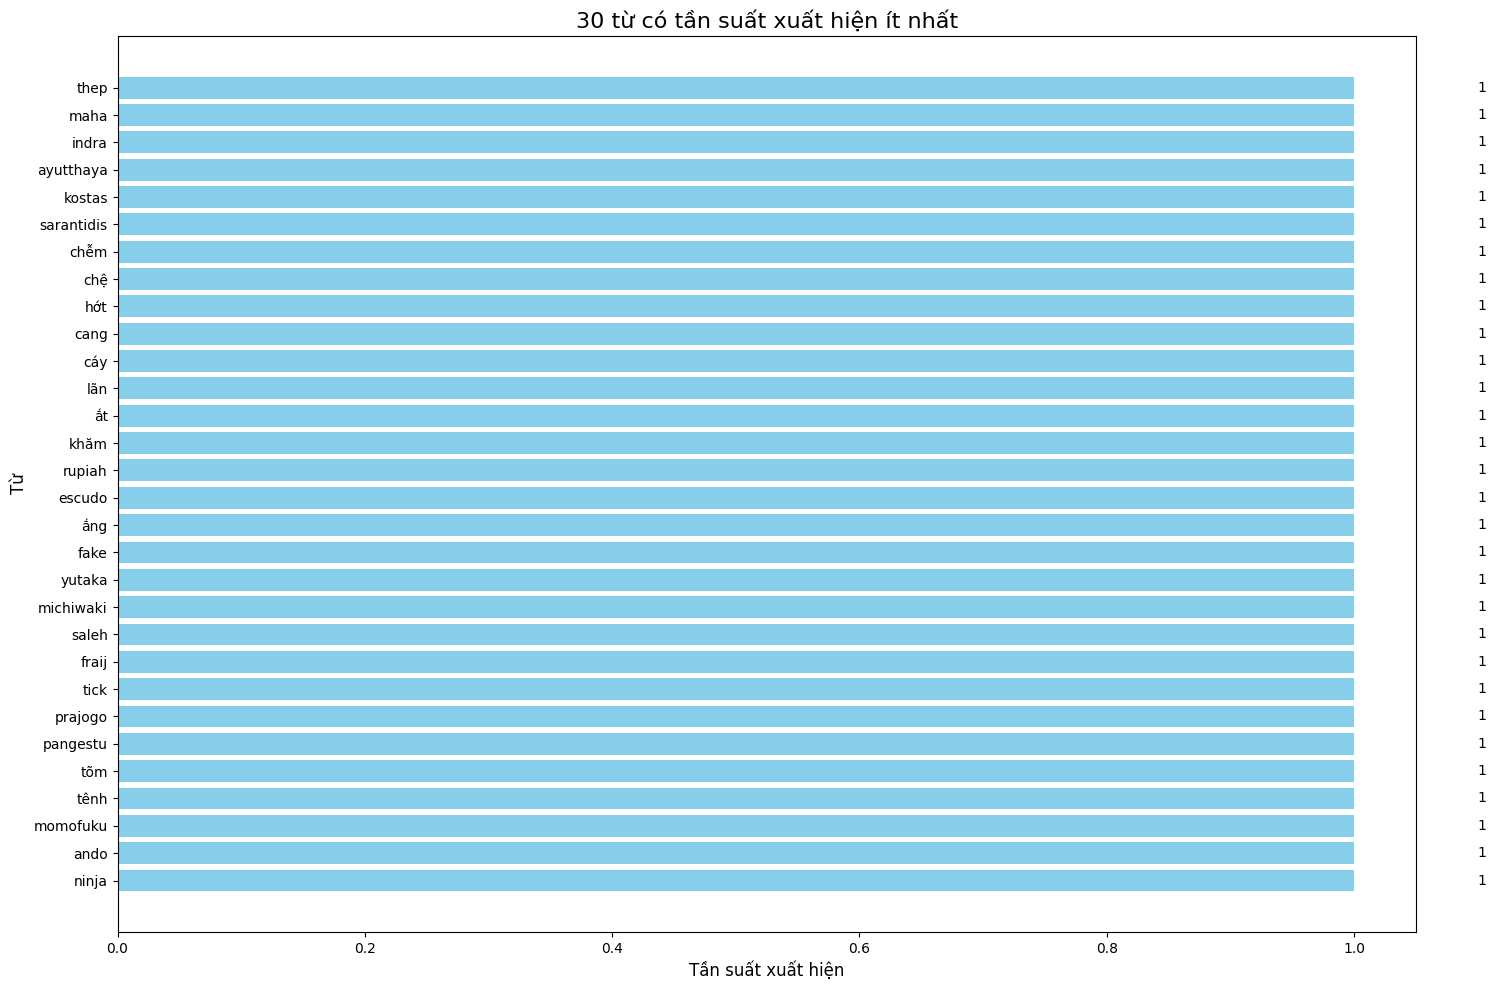

In [13]:
# Bước 3: Vẽ biểu đồ 30 từ có tần suất xuất hiện ít nhất
plot_least_frequent_words(vocabulary, 30)

Đã lưu biểu đồ 50 từ có tần suất xuất hiện ít nhất vào 'least_frequent_words.png'


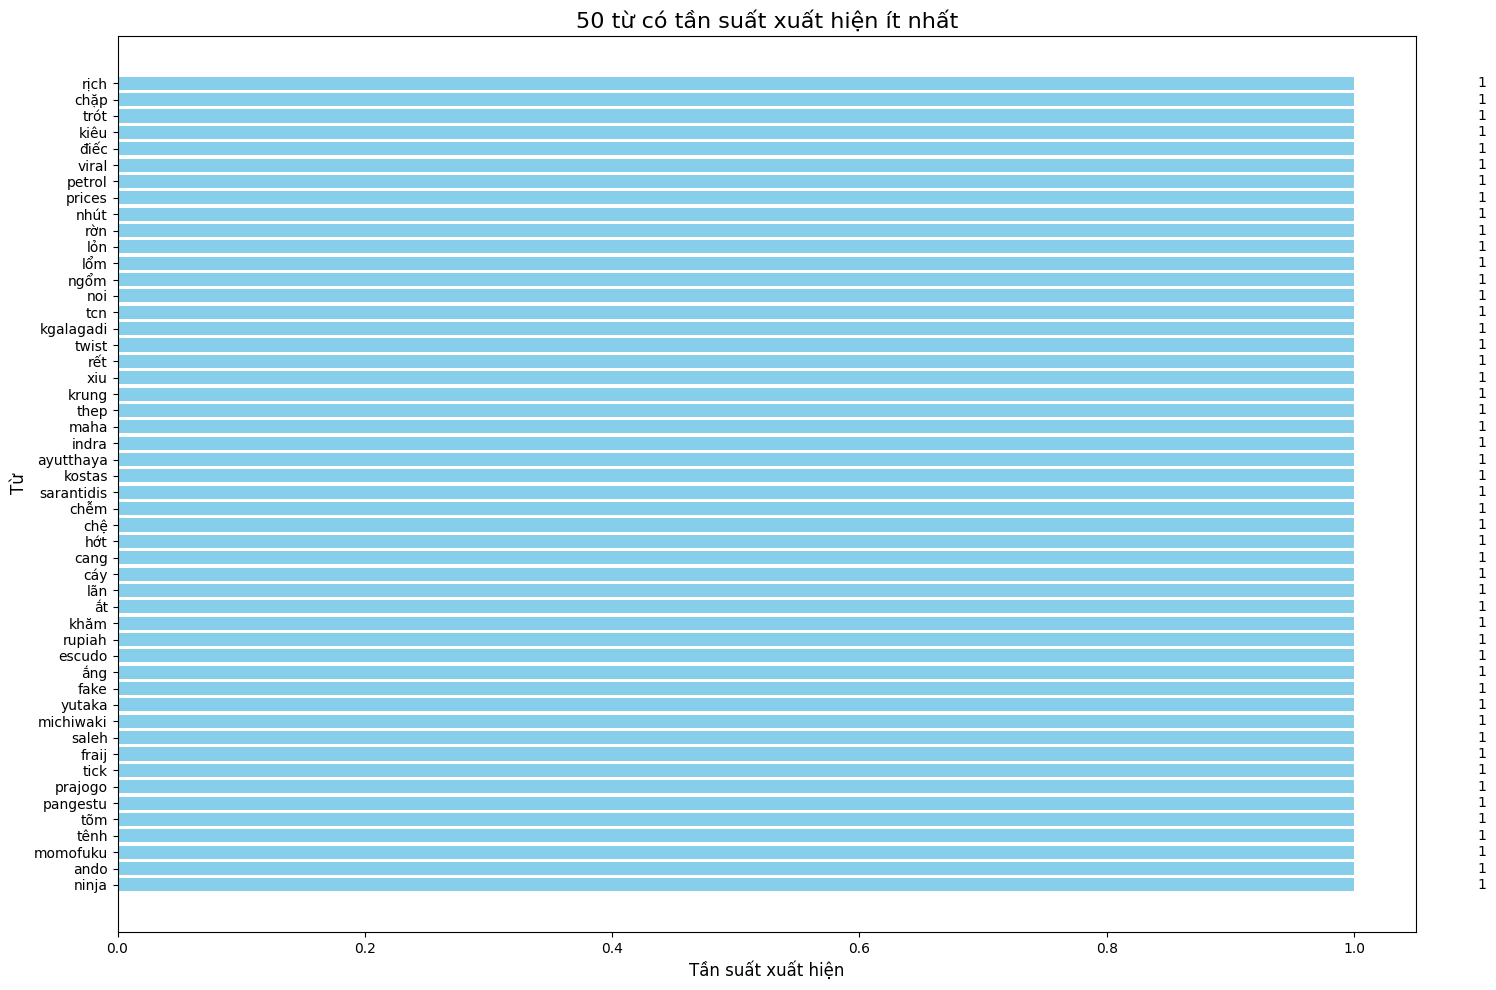

In [14]:
# Bước 3: Vẽ biểu đồ 50 từ có tần suất xuất hiện ít nhất
plot_least_frequent_words(vocabulary, 50)

Đã lưu biểu đồ phân bố tần suất từ vào 'frequency_distribution.png'


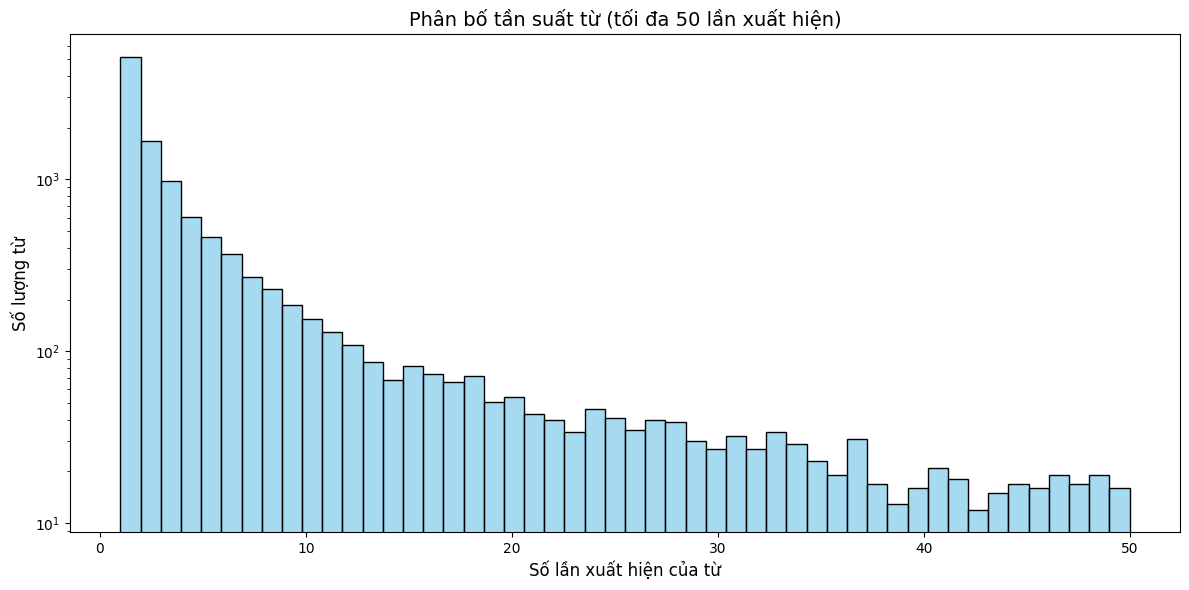

In [15]:
plot_frequency_distribution(vocabulary, max_freq=50, log_scale=True)

Đã lưu biểu đồ phân bố tần suất đầy đủ vào 'zipf_full_distribution.png'


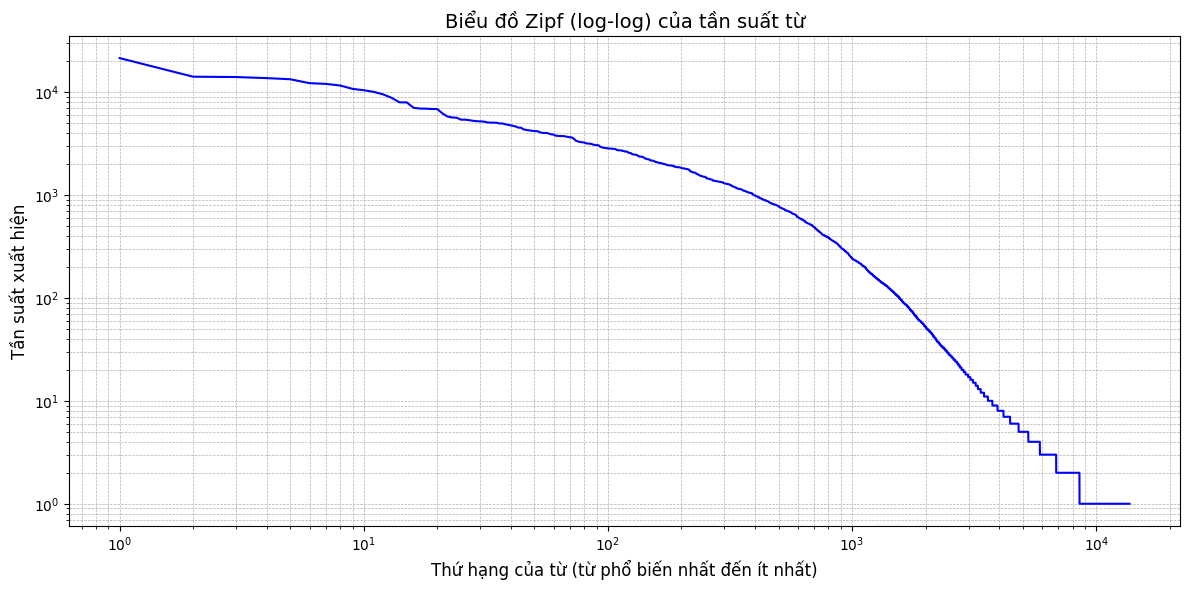

In [16]:
plot_full_frequency_distribution(vocabulary, log_scale=True)

Đã lưu biểu đồ top 50 từ phổ biến vào 'top_frequent_words.png'


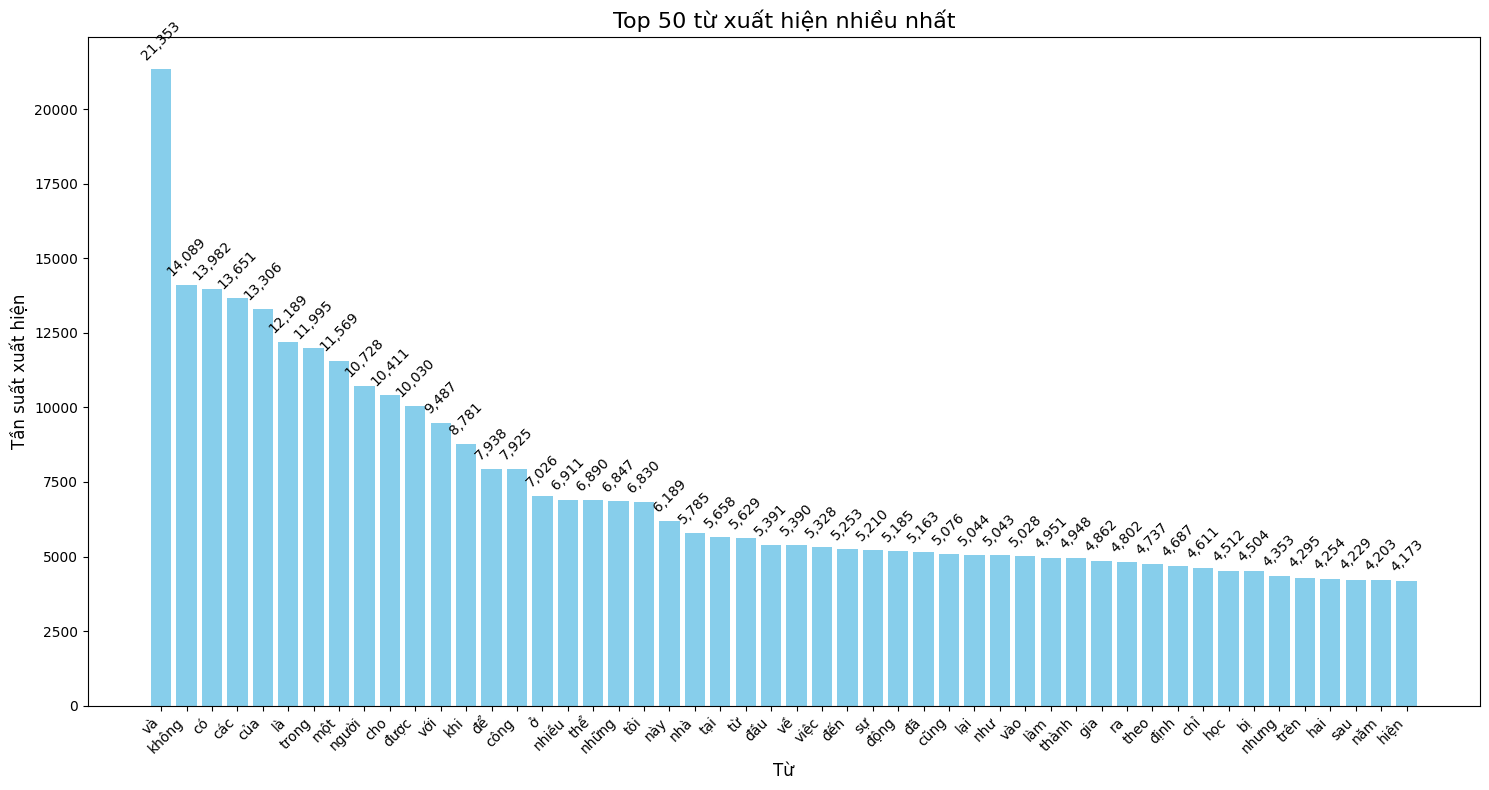

In [17]:
plot_top_frequent_words(vocabulary, n=50)

Đang lọc câu: 100%|██████████| 137956/137956 [00:00<00:00, 384483.88it/s]


Đã lọc xong! Kết quả được lưu tại: raw_data/data_sau_khi_clean.txt
Số từ ban đầu: 13691
Số từ sau khi lọc: 2460
Số câu ban đầu: 137956
Số câu sau khi lọc: 106536
Đã loại bỏ 31420 câu chứa từ hiếm
Hoàn thành tất cả các bước xử lý!
Đã lưu biểu đồ 30 từ có tần suất xuất hiện ít nhất vào 'least_frequent_words.png'


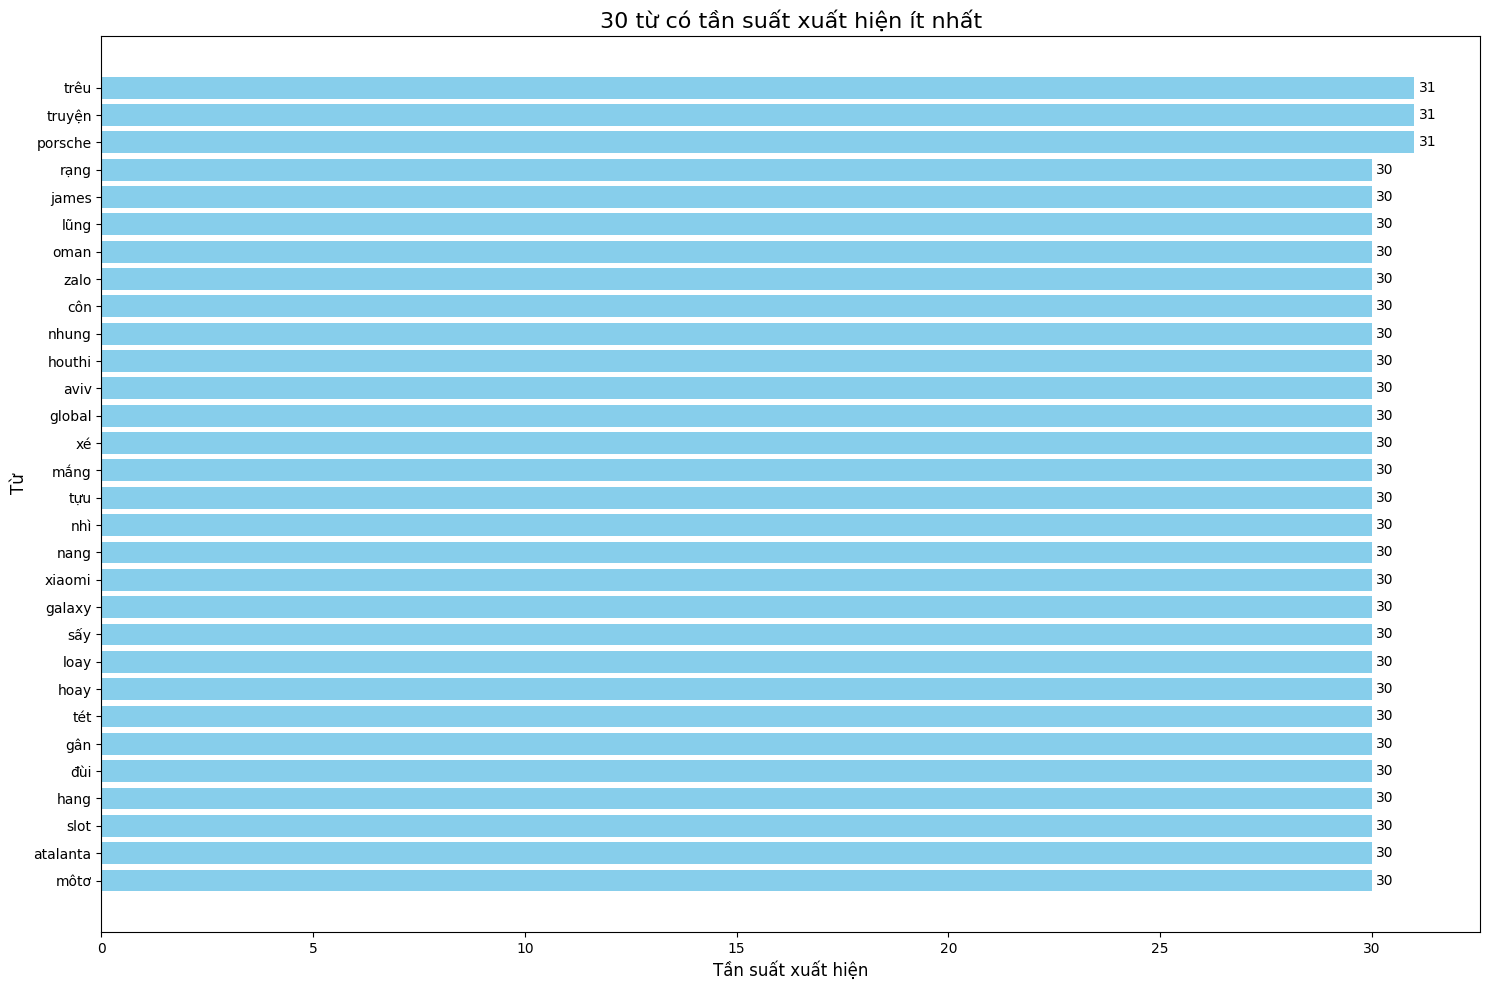

In [18]:
min_count = 30
filtered_output = "raw_data/data_sau_khi_clean.txt"
filtered_vocab, filtered_sentences = filter_vocabulary(vocabulary, normalized_sentences, min_count, filtered_output)

print("Hoàn thành tất cả các bước xử lý!")

plot_least_frequent_words(Counter(filtered_vocab), 30)

In [19]:
import random
import os

def remove_vietnamese_accents(text):
    """Loại bỏ dấu tiếng Việt từ chuỗi văn bản"""
    accent_map = {
        'à': 'a', 'á': 'a', 'ả': 'a', 'ã': 'a', 'ạ': 'a',
        'ă': 'a', 'ằ': 'a', 'ắ': 'a', 'ẳ': 'a', 'ẵ': 'a', 'ặ': 'a',
        'â': 'a', 'ầ': 'a', 'ấ': 'a', 'ẩ': 'a', 'ẫ': 'a', 'ậ': 'a',
        'đ': 'd',
        'è': 'e', 'é': 'e', 'ẻ': 'e', 'ẽ': 'e', 'ẹ': 'e',
        'ê': 'e', 'ề': 'e', 'ế': 'e', 'ể': 'e', 'ễ': 'e', 'ệ': 'e',
        'ì': 'i', 'í': 'i', 'ỉ': 'i', 'ĩ': 'i', 'ị': 'i',
        'ò': 'o', 'ó': 'o', 'ỏ': 'o', 'õ': 'o', 'ọ': 'o',
        'ô': 'o', 'ồ': 'o', 'ố': 'o', 'ổ': 'o', 'ỗ': 'o', 'ộ': 'o',
        'ơ': 'o', 'ờ': 'o', 'ớ': 'o', 'ở': 'o', 'ỡ': 'o', 'ợ': 'o',
        'ù': 'u', 'ú': 'u', 'ủ': 'u', 'ũ': 'u', 'ụ': 'u',
        'ư': 'u', 'ừ': 'u', 'ứ': 'u', 'ử': 'u', 'ữ': 'u', 'ự': 'u',
        'ỳ': 'y', 'ý': 'y', 'ỷ': 'y', 'ỹ': 'y', 'ỵ': 'y',
        'À': 'A', 'Á': 'A', 'Ả': 'A', 'Ã': 'A', 'Ạ': 'A',
        'Ă': 'A', 'Ằ': 'A', 'Ắ': 'A', 'Ẳ': 'A', 'Ẵ': 'A', 'Ặ': 'A',
        'Â': 'A', 'Ầ': 'A', 'Ấ': 'A', 'Ẩ': 'A', 'Ẫ': 'A', 'Ậ': 'A',
        'Đ': 'D',
        'È': 'E', 'É': 'E', 'Ẻ': 'E', 'Ẽ': 'E', 'Ẹ': 'E',
        'Ê': 'E', 'Ề': 'E', 'Ế': 'E', 'Ể': 'E', 'Ễ': 'E', 'Ệ': 'E',
        'Ì': 'I', 'Í': 'I', 'Ỉ': 'I', 'Ĩ': 'I', 'Ị': 'I',
        'Ò': 'O', 'Ó': 'O', 'Ỏ': 'O', 'Õ': 'O', 'Ọ': 'O',
        'Ô': 'O', 'Ồ': 'O', 'Ố': 'O', 'Ổ': 'O', 'Ỗ': 'O', 'Ộ': 'O',
        'Ơ': 'O', 'Ờ': 'O', 'Ớ': 'O', 'Ở': 'O', 'Ỡ': 'O', 'Ợ': 'O',
        'Ù': 'U', 'Ú': 'U', 'Ủ': 'U', 'Ũ': 'U', 'Ụ': 'U',
        'Ư': 'U', 'Ừ': 'U', 'Ứ': 'U', 'Ử': 'U', 'Ữ': 'U', 'Ự': 'U',
        'Ỳ': 'Y', 'Ý': 'Y', 'Ỷ': 'Y', 'Ỹ': 'Y', 'Ỵ': 'Y'
    }
    
    result = ""
    for char in text:
        result += accent_map.get(char, char)
    
    return result

def split_large_txt(input_path, train_path, val_path, test_path=None, train_ratio=0.6, val_ratio=0.2):
    """
    Chia dữ liệu thành train, val, test theo tỉ lệ chỉ định (mặc định 6:2:2)
    Đồng thời loại bỏ dấu tiếng Việt
    
    Args:
        input_path: Đường dẫn file đầu vào
        train_path: Đường dẫn file train (label.txt)
        val_path: Đường dẫn file val (label.txt)
        test_path: Đường dẫn file test (label.txt), nếu None thì không tách test
        train_ratio: Tỉ lệ train (mặc định 0.6 tức 60%)
        val_ratio: Tỉ lệ val (mặc định 0.2 tức 20%)
    """
    # Đọc file đầu vào
    with open(input_path, 'r', encoding='utf-8') as f:
        lines = [line.rstrip() for line in f if line.strip()]
    
    total = len(lines)
    print(f"Tổng số dòng: {total}")

    random.shuffle(lines)

    # Tính kích thước tập dữ liệu
    train_size = int(total * train_ratio)
    val_size = int(total * val_ratio)
    test_size = total - train_size - val_size
    
    train_data = lines[:train_size]
    val_data = lines[train_size:train_size + val_size]
    test_data = lines[train_size + val_size:] if test_path else []
    
    # Tách đường dẫn để lấy thư mục
    train_dir = os.path.dirname(train_path)
    val_dir = os.path.dirname(val_path)
    
    # Tạo thư mục nếu chưa có
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    
    if test_path:
        test_dir = os.path.dirname(test_path)
        os.makedirs(test_dir, exist_ok=True)
    
    # Ghi dữ liệu TRAIN
    with open(train_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(train_data) + '\n')
    
    train_no_accent_path = train_path.replace('label.txt', 'cau_khong_dau.txt')
    with open(train_no_accent_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join([remove_vietnamese_accents(line) for line in train_data]) + '\n')
    
    print(f"✅ Train: {train_size} dòng")
    print(f"   - {train_path}")
    print(f"   - {train_no_accent_path}")
    
    # Ghi dữ liệu VAL
    with open(val_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(val_data) + '\n')
    
    val_no_accent_path = val_path.replace('label.txt', 'cau_khong_dau.txt')
    with open(val_no_accent_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join([remove_vietnamese_accents(line) for line in val_data]) + '\n')
    
    print(f"✅ Val:   {val_size} dòng")
    print(f"   - {val_path}")
    print(f"   - {val_no_accent_path}")
    
    # Ghi dữ liệu TEST (nếu có)
    if test_path:
        with open(test_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(test_data) + '\n')
        
        test_no_accent_path = test_path.replace('label.txt', 'cau_khong_dau.txt')
        with open(test_no_accent_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join([remove_vietnamese_accents(line) for line in test_data]) + '\n')
        
        print(f"✅ Test:  {test_size} dòng")
        print(f"   - {test_path}")
        print(f"   - {test_no_accent_path}")


In [20]:
# Cập nhật: Sử dụng file đã lọc để chia train/val/test
split_large_txt(
    input_path='raw_data/data_sau_khi_clean.txt',
    train_path='dataset/train/label.txt',
    val_path='dataset/val/label.txt',
    test_path='dataset/test/label.txt',
    train_ratio=0.6,
    val_ratio=0.2
)


Tổng số dòng: 106536
✅ Train: 63921 dòng
   - dataset/train/label.txt
   - dataset/train/cau_khong_dau.txt
✅ Val:   21307 dòng
   - dataset/val/label.txt
   - dataset/val/cau_khong_dau.txt
✅ Test:  21308 dòng
   - dataset/test/label.txt
   - dataset/test/cau_khong_dau.txt


PHÂN TÍCH DỮ LIỆU TRƯỚC VÀ SAU KHI LÀM SẠCH VÀ CHUẨN HÓA

📊 Đang phân tích dữ liệu thô...
📊 Đang phân tích dữ liệu đã lọc...

📈 BẢNG SO SÁNH DỮ LIỆU:
                              Chỉ số  Dữ liệu thô  Dữ liệu đã xử lý
                      📝 Số lượng câu     91976.00         106536.00
        🆎 Độ dài trung bình câu (từ)        28.33             10.56
⚠️ Tỷ lệ câu chứa ký tự đặc biệt (%)        98.54              0.00
         🔢 Tỷ lệ câu chứa dãy số (%)        34.59              0.10

📉 MỨC ĐỘ THAY ĐỔI (So với dữ liệu thô):
                    Chỉ số Mức thay đổi
           Số câu giảm (%)      -15.83%
Độ dài trung bình thay đổi       -17.77
   Ký tự đặc biệt giảm (%)       100.0%
           Dãy số giảm (%)       99.71%

✅ Biểu đồ so sánh đã được lưu vào 'data_comparison.png'


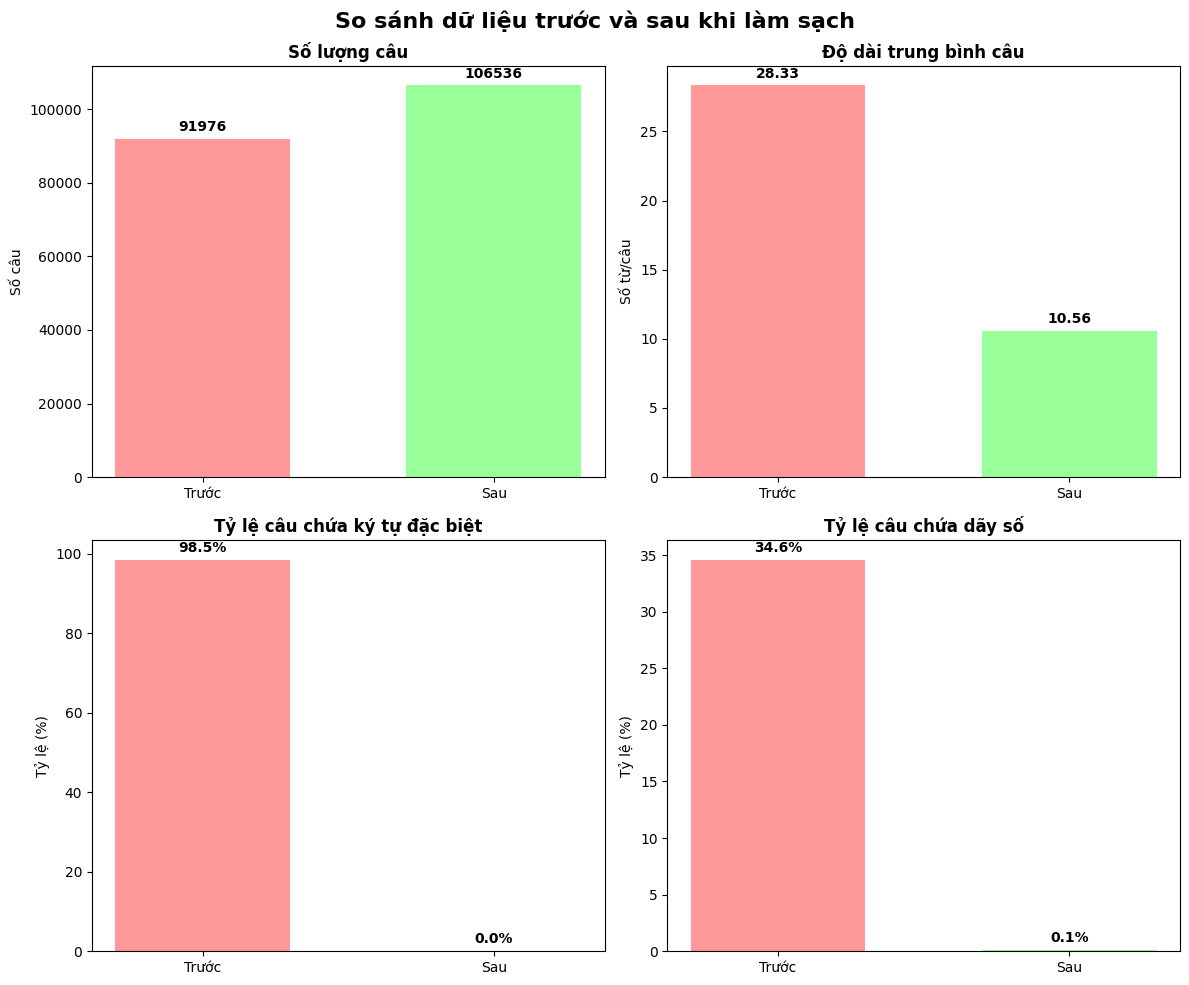

In [21]:
import re
import pandas as pd
from collections import Counter

def analyze_data(file_path):
    """
    Phân tích dữ liệu từ file và tính toán các thống kê.
    
    Returns:
        dict: Chứa các thống kê về dữ liệu
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            sentences = [line.strip() for line in f if line.strip()]
    except FileNotFoundError:
        print(f"File không tồn tại: {file_path}")
        return None
    
    if not sentences:
        print(f"File trống: {file_path}")
        return None
    
    # 1. Số lượng câu
    num_sentences = len(sentences)
    
    # 2. Số lượng từ phân biệt
    all_words = []
    for sentence in sentences:
        words = sentence.split()
        all_words.extend(words)
    
    distinct_words = len(set(all_words))
    
    # 3. Độ dài trung bình câu (tính theo từ)
    total_words = len(all_words)
    avg_sentence_length = total_words / num_sentences if num_sentences > 0 else 0
    
    # 4. Tỷ lệ câu chứa ký tự đặc biệt
    special_char_pattern = r'[!@#$%^&*()_=+\[\]{};:\'",.<>?/\\|`~]'
    sentences_with_special = sum(1 for s in sentences if re.search(special_char_pattern, s))
    ratio_special_chars = (sentences_with_special / num_sentences) * 100 if num_sentences > 0 else 0
    
    # 5. Tỷ lệ câu chứa dãy số
    digit_pattern = r'\d+'
    sentences_with_digits = sum(1 for s in sentences if re.search(digit_pattern, s))
    ratio_digits = (sentences_with_digits / num_sentences) * 100 if num_sentences > 0 else 0
    
    return {
        'file': file_path,
        'num_sentences': num_sentences,
        'distinct_words': distinct_words,
        'total_words': total_words,
        'avg_sentence_length': round(avg_sentence_length, 2),
        'ratio_special_chars': round(ratio_special_chars, 2),
        'ratio_digits': round(ratio_digits, 2)
    }

# Phân tích dữ liệu thô (trước khi xử lý)
print("=" * 80)
print("PHÂN TÍCH DỮ LIỆU TRƯỚC VÀ SAU KHI LÀM SẠCH VÀ CHUẨN HÓA")
print("=" * 80)

print("\n📊 Đang phân tích dữ liệu thô...")
raw_data_stats = analyze_data("raw_data/crawled_news_pagination.txt")

# Phân tích dữ liệu đã lọc
print("📊 Đang phân tích dữ liệu đã lọc...")
filtered_data_stats = analyze_data("raw_data/data_sau_khi_clean.txt")

# Tạo bảng so sánh
if raw_data_stats and filtered_data_stats:
    comparison_data = {
        'Chỉ số': [
            '📝 Số lượng câu',
            '🆎 Độ dài trung bình câu (từ)',
            '⚠️ Tỷ lệ câu chứa ký tự đặc biệt (%)',
            '🔢 Tỷ lệ câu chứa dãy số (%)'
        ],
        'Dữ liệu thô': [
            raw_data_stats['num_sentences'],
            raw_data_stats['avg_sentence_length'],
            raw_data_stats['ratio_special_chars'],
            raw_data_stats['ratio_digits']
        ],
        'Dữ liệu đã xử lý': [
            filtered_data_stats['num_sentences'],
            filtered_data_stats['avg_sentence_length'],
            filtered_data_stats['ratio_special_chars'],
            filtered_data_stats['ratio_digits']
        ]
    }
    
    df_comparison = pd.DataFrame(comparison_data)
    print("\n" + "=" * 80)
    print("📈 BẢNG SO SÁNH DỮ LIỆU:")
    print("=" * 80)
    print(df_comparison.to_string(index=False))
    print("=" * 80)
    
    # Tính toán sự thay đổi
    print("\n" + "=" * 80)
    print("📉 MỨC ĐỘ THAY ĐỔI (So với dữ liệu thô):")
    print("=" * 80)
    
    changes = {
        'Chỉ số': [
            'Số câu giảm (%)',
            'Độ dài trung bình thay đổi',
            'Ký tự đặc biệt giảm (%)',
            'Dãy số giảm (%)'
        ],
        'Mức thay đổi': [
            f"{round((1 - filtered_data_stats['num_sentences']/raw_data_stats['num_sentences']) * 100, 2)}%",
            f"{filtered_data_stats['avg_sentence_length'] - raw_data_stats['avg_sentence_length']:+.2f}",
            f"{round((1 - filtered_data_stats['ratio_special_chars']/raw_data_stats['ratio_special_chars']) * 100, 2)}%" if raw_data_stats['ratio_special_chars'] > 0 else "N/A",
            f"{round((1 - filtered_data_stats['ratio_digits']/raw_data_stats['ratio_digits']) * 100, 2)}%" if raw_data_stats['ratio_digits'] > 0 else "N/A"
        ]
    }
    
    df_changes = pd.DataFrame(changes)
    print(df_changes.to_string(index=False))
    print("=" * 80)
    
    # Vẽ biểu đồ so sánh
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('So sánh dữ liệu trước và sau khi làm sạch', fontsize=16, fontweight='bold')
    
    # 1. So sánh số lượng câu
    stages = ['Trước', 'Sau']
    num_sentences = [raw_data_stats['num_sentences'], filtered_data_stats['num_sentences']]
    colors = ['#ff9999', '#99ff99']
    axes[0, 0].bar(stages, num_sentences, color=colors, width=0.6)
    axes[0, 0].set_title('Số lượng câu', fontweight='bold')
    axes[0, 0].set_ylabel('Số câu')
    for i, v in enumerate(num_sentences):
        axes[0, 0].text(i, v + max(num_sentences)*0.02, str(v), ha='center', fontweight='bold')
    
    # 2. So sánh độ dài trung bình câu
    avg_length = [raw_data_stats['avg_sentence_length'], filtered_data_stats['avg_sentence_length']]
    axes[0, 1].bar(stages, avg_length, color=colors, width=0.6)
    axes[0, 1].set_title('Độ dài trung bình câu', fontweight='bold')
    axes[0, 1].set_ylabel('Số từ/câu')
    for i, v in enumerate(avg_length):
        axes[0, 1].text(i, v + max(avg_length)*0.02, f'{v:.2f}', ha='center', fontweight='bold')
    
    # 3. Tỷ lệ câu chứa ký tự đặc biệt
    ratio_special = [raw_data_stats['ratio_special_chars'], filtered_data_stats['ratio_special_chars']]
    axes[1, 0].bar(stages, ratio_special, color=colors, width=0.6)
    axes[1, 0].set_title('Tỷ lệ câu chứa ký tự đặc biệt', fontweight='bold')
    axes[1, 0].set_ylabel('Tỷ lệ (%)')
    for i, v in enumerate(ratio_special):
        axes[1, 0].text(i, v + max(ratio_special)*0.02, f'{v:.1f}%', ha='center', fontweight='bold')
    
    # 4. Tỷ lệ câu chứa dãy số
    ratio_digit = [raw_data_stats['ratio_digits'], filtered_data_stats['ratio_digits']]
    axes[1, 1].bar(stages, ratio_digit, color=colors, width=0.6)
    axes[1, 1].set_title('Tỷ lệ câu chứa dãy số', fontweight='bold')
    axes[1, 1].set_ylabel('Tỷ lệ (%)')
    for i, v in enumerate(ratio_digit):
        axes[1, 1].text(i, v + max(ratio_digit)*0.02, f'{v:.1f}%', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('data_comparison.png', dpi=300, bbox_inches='tight')
    print("\n✅ Biểu đồ so sánh đã được lưu vào 'data_comparison.png'")
    plt.show()
    
else:
    print("❌ Không thể phân tích dữ liệu. Kiểm tra lại đường dẫn file.")